# Grocery Habit

My grocery habit in the 15 months. I mainly shop at three places: Publix, a local Asian market, and Walmart. Publix is for the quality weekly grocery staples, the local Asian market is for my asian cravings, and Walmart is for when i need to bulk up on cleaning supplies or non food items. The non food items at Publix are overpriced. 

## Import packages

In [1]:
import pandas as pd
import numpy as np 
import matplotlib
import matplotlib.pyplot as plt
%matplotlib inline
from scipy import stats
from datetime import datetime
from sklearn import preprocessing
from sklearn.model_selection import KFold
from sklearn.linear_model import LinearRegression
import statsmodels.api as sm
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import GradientBoostingRegressor

## Load dataset

In [2]:
# Creating the table in dataframe from a csv file
df = pd.read_csv(r"C:\Users\Clair\Documents\Code Development\Python Local\personal_finance\Grocery Habit.csv")

In [3]:
# Summary of the table
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 234 entries, 0 to 233
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Date         234 non-null    object 
 1   Month        234 non-null    int64  
 2   Store        234 non-null    object 
 3   Money Spent  234 non-null    float64
dtypes: float64(1), int64(1), object(2)
memory usage: 7.4+ KB


<Axes: >

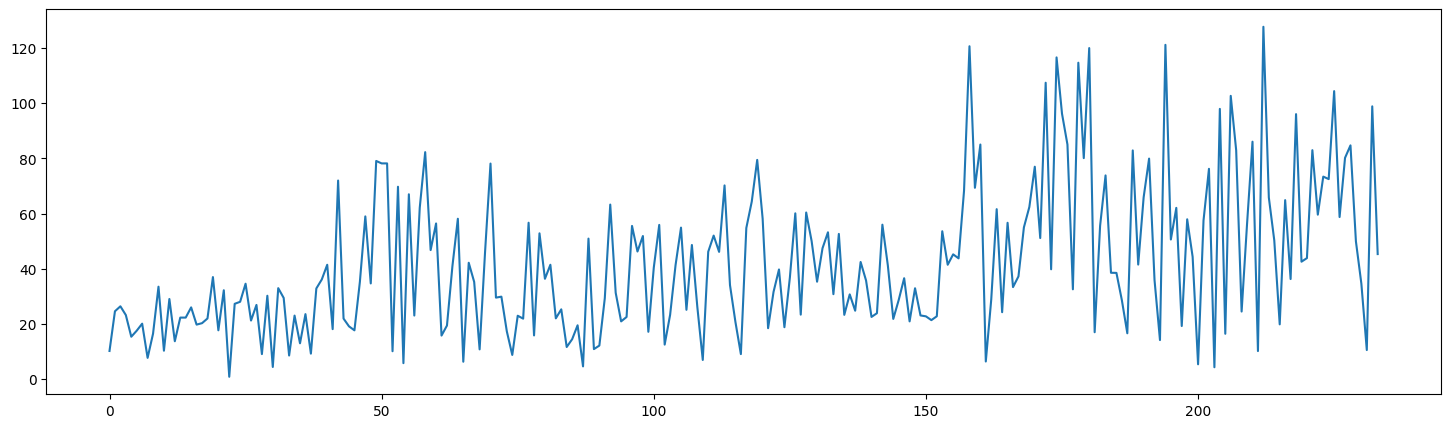

In [4]:
# Big picture - identifying pattern with money spending
df['Money Spent'].plot(figsize = (18,5))

In [5]:
# Checking for null values
df.isnull().values.any()

False

## Clean/modify data

In [6]:
# Converting the date object mm/dd/yyyy to another date object mm-dd-yyyy
df["Date"] = pd.to_datetime(df["Date"]).dt.date
print(df.dtypes,'\n')

# Previewing the table - just checking the Date columns is properly converted
print(df.head(2))

Date            object
Month            int64
Store           object
Money Spent    float64
dtype: object 

         Date  Month Store  Money Spent
0  2023-03-13      3  Aldi        10.25
1  2023-03-17      3  Aldi        24.62


### High level

In [7]:
# Extremes
Cheap = df['Money Spent'].min()
Expensive = df['Money Spent'].max()
Paid = df['Money Spent'].sum().round(2)

print(f'Most cheap trip:\n $',Cheap,'\n')
print(f'Most expensive trip:\n $',Expensive,'\n')
print(f'Amount spent toward feeding myself thus far:\n $',Paid,'\n')

Most cheap trip:
 $ 0.9 

Most expensive trip:
 $ 127.63 

Amount spent toward feeding myself thus far:
 $ 9777.25 



In [8]:
# Basic stats by store
print('The amount of money I spend at each of the main stores:')
Store_group = df.groupby(['Store']).agg({'Money Spent': ['min', 'max', 'mean', 'median']}).round(2)
Store_group.columns = ['min', 'max', 'mean', 'median']
Store_group.reset_index()
Store_group

The amount of money I spend at each of the main stores:


,min,max,mean,median
Store,,,,
Aldi,0.90,37.00,20.82,22.17
Asia Pacific Supermarket,18.15,71.96,40.12,36.13
Fairway Market,19.16,21.97,20.56,20.56
Food City,4.66,82.24,36.42,33.01
Kimchee Asian Market,6.99,6.99,6.99,6.99
Local Asian Market,9.11,79.43,39.13,36.68
Publix,6.43,120.58,61.02,56.66
The Fresh Market,14.19,14.19,14.19,14.19
Walmart,4.35,127.63,59.46,58.33


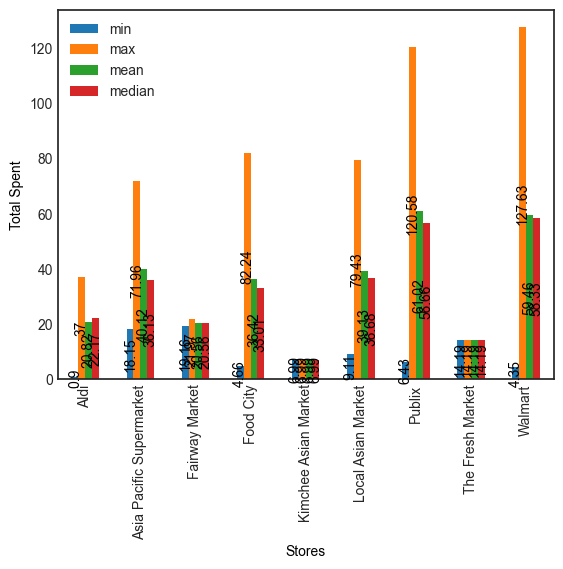

In [9]:
# Stats grouped by store viz
matplotlib.style.use('seaborn-v0_8-white') 
ax = Store_group.plot.bar()
for container in ax.containers:
    ax.bar_label(container, label_type = 'center', rotation = 'vertical', color = 'black', fontsize = 10)

plt.xlabel('Stores', size = 10, color = 'black')
plt.ylabel('Total Spent', size = 10, color = 'black')


plt.show()

In [10]:
# Count of trips by store in the last x months
Trip_count = df['Store'].value_counts()
print(Trip_count)

Store
Food City                   64
Local Asian Market          48
Walmart                     40
Aldi                        38
Publix                      35
Asia Pacific Supermarket     5
Fairway Market               2
Kimchee Asian Market         1
The Fresh Market             1
Name: count, dtype: int64


<Axes: ylabel='count'>

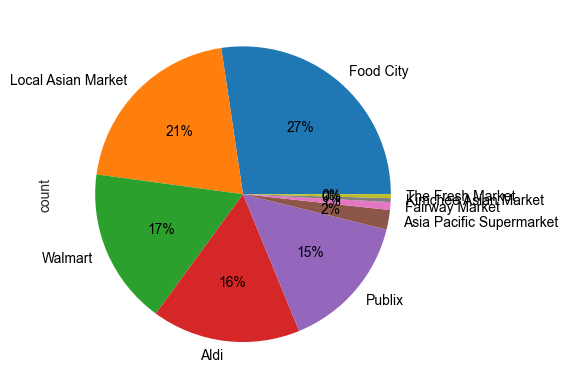

In [11]:
Trip_count.plot(kind = 'pie', y = 'Store', autopct = '%1.0f%%', textprops = {'color':'black'})

### Total

#### Monthly

In [12]:
# Spending per month
Monthly_split_total = df.groupby('Month')['Money Spent'].sum()
Monthly_split_total

Month
1      819.17
2      890.44
3      759.83
4      116.92
5      512.24
6      937.48
7     1380.68
8      921.43
9      785.17
10     681.01
11    1083.81
12     889.07
Name: Money Spent, dtype: float64

In [13]:
# Spending per month avg
Monthly_split_avg = df.groupby('Month')['Money Spent'].median()
Monthly_split_avg

Month
1     35.250
2     35.720
3     32.990
4     34.700
5     39.610
6     33.520
7     41.405
8     28.720
9     36.095
10    42.570
11    40.900
12    34.090
Name: Money Spent, dtype: float64

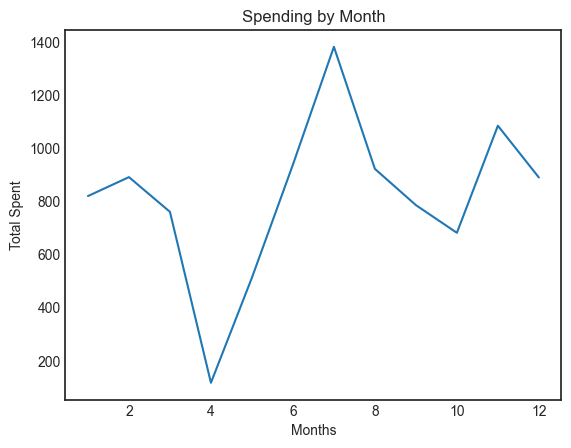

In [14]:
Monthly_split_total.plot(kind = 'line')

plt.title('Spending by Month')
plt.xlabel('Months')
plt.ylabel('Total Spent')

plt.show()

#### Store

In [15]:
# Total Spending by store
Store_split = df.groupby('Store')['Money Spent'].sum()
Store_split

Store
Aldi                         791.18
Asia Pacific Supermarket     200.58
Fairway Market                41.13
Food City                   2330.64
Kimchee Asian Market           6.99
Local Asian Market          1878.25
Publix                      2135.75
The Fresh Market              14.19
Walmart                     2378.54
Name: Money Spent, dtype: float64

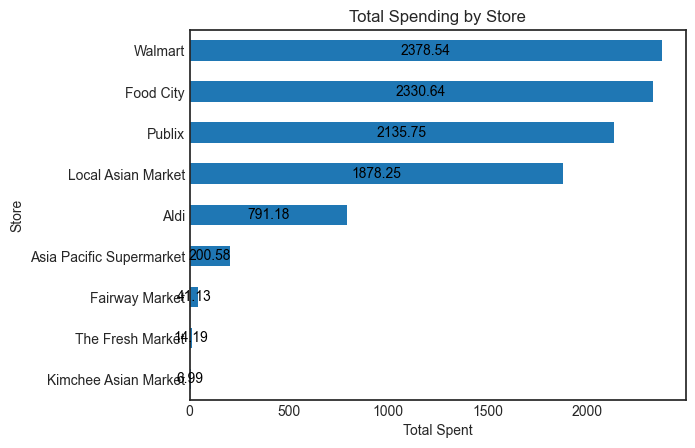

In [16]:
# sort the values in desc order so the barh will be most to least
Store_split = Store_split.sort_values(ascending=True) 
ax = Store_split.plot.barh()
for container in ax.containers:
    ax.bar_label(container, label_type = 'center', color = 'black', fontsize = 10)
    

plt.title('Total Spending by Store')
plt.xlabel('Total Spent')
plt.ylabel('Store')

plt.show()